# Makoma Isabelle Pilusa 
# ST10145212
# POE Final

## Exploratory Data Analysis EDA

#### EDA will be conducted to understand the structure, quality and characteristics of the dataset before training a model. 
#### The analysis will focus on a pateints feedback and sentiment data. The objective is to identify key areas of concern and classify customer senitemnt.
#### THE EDA will investigate:
#### - Datatset structure and quality
#### - Missing values and duplicates
#### - Sentiment classes distrubution 
#### - Themes distribution 
#### - Satifaction and readmission patterns 
#### - Relationships betweem the sentiments and themes 
#### - Characterisitics of feedback text 

#### The findings of the EDA will help guide with the preprocessing, feature selection, and model training stages for the project

In [3]:
## Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [4]:
!pip install wordcloud

In [5]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
plt.style.use('default')

In [9]:
df = pd.read_excel("patient_feedback_dataset.xlsx")
df.head()

,Theme,Feedback,Sentiment,Satisfaction,Readmission
0,discharge,Discharge instructions were very clear,1,4,1
1,communication,I felt the doctor used too much medical jargon,1,5,0
2,medication,I appreciated the reminders about my medicines,1,4,0
3,discharge,Instructions after discharge were not helpful,0,1,1
4,discharge,Instructions after discharge were not helpful,0,2,1


#### Dataset Preview:
#### The first few records are displayed to understand the structure of the dataset and verify the data has been loaded correctly

In [10]:
print("Shape:", df.shape)
df.info()

Shape: (1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Theme         1000 non-null   object
 1   Feedback      1000 non-null   object
 2   Sentiment     1000 non-null   int64 
 3   Satisfaction  1000 non-null   int64 
 4   Readmission   1000 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 39.2+ KB


#### Dataset Structure

#### This step identifies:

#### - Number of records
#### - Number of features
#### - Data types
#### - Potential issues requiring preprocessing

In [11]:
df.isnull().sum()

Theme           0
Feedback        0
Sentiment       0
Satisfaction    0
Readmission     0
dtype: int64

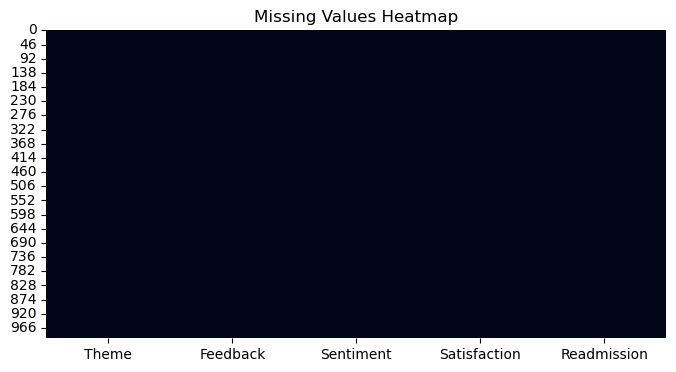

In [12]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

#### This analysis identifies whether any records require cleaning or imputation before training the sentiment classification model.

In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 905


#### Duplicate reviews can introduce bias into the model by over-representing specific opinions. Duplicates will be removed

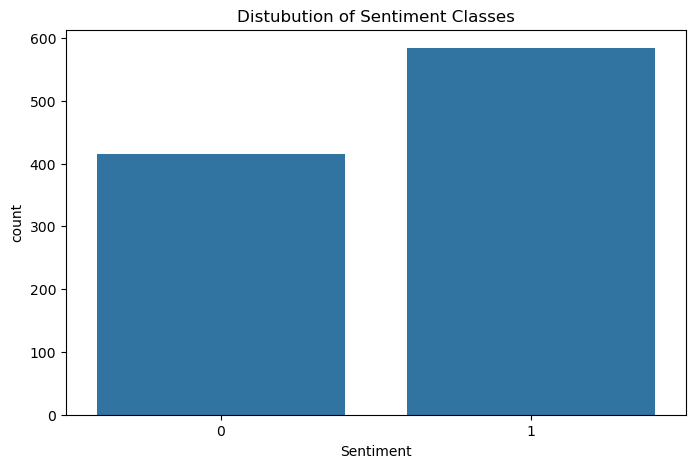

In [16]:
## Sentiment Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Sentiment')
plt.title("Distubution of Sentiment Classes")
plt.show()

#### The sentiment variable is the target variable for classification. Analysing class distribution helps determine whether the dataset is balanced.

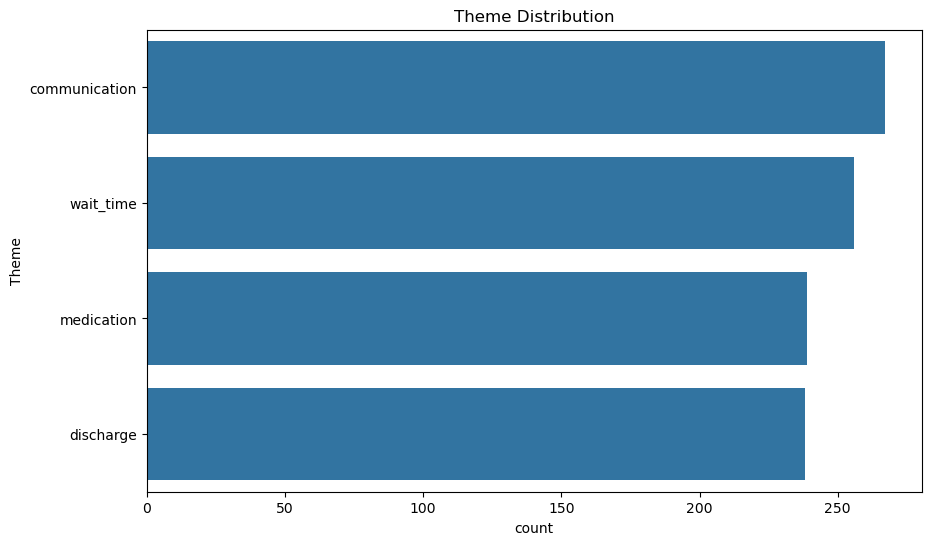

In [18]:
##Theme Distribution
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    y='Theme',
    order=df['Theme'].value_counts().index
)

plt.title("Theme Distribution")
plt.show()

#### Themes represent the broad areas discussed by patients. Analysing theme frequencies helps identify the most common customer concerns and provides business insights into the areas requiring improvement. Commuication has the highest count and is a recurring theme

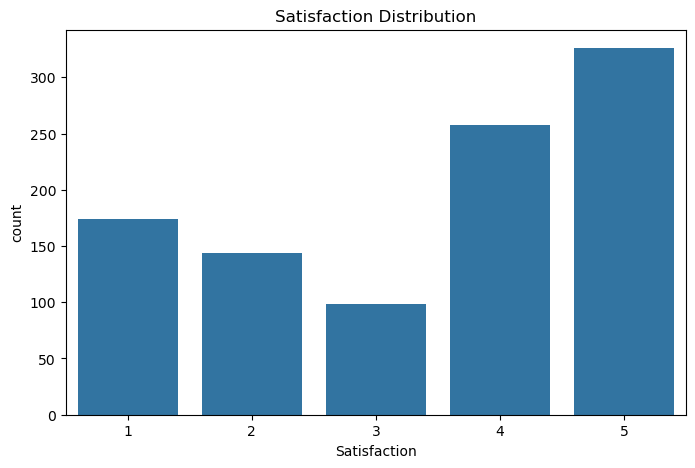

In [19]:
##Satisfcation Distribution
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Satisfaction')

plt.title("Satisfaction Distribution")
plt.show()

#### Satisfaction levels provide additional context regarding patient experiences. Level 5 of satisifcation has the highest count

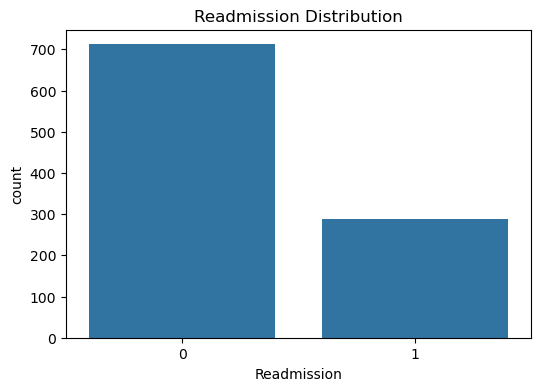

In [21]:
## Readmission Analysis 
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Readmission')

plt.title("Readmission Distribution")
plt.show()

#### Readmission information may indicate whether patient experiences influence future healthcare outcomes. 0 having the highest count means there will be less readmission 

In [23]:
## Theme vs Sentiment 
theme_sentiment = pd.crosstab(
    df['Theme'],
    df['Sentiment']
)

theme_sentiment

Sentiment,0,1
Theme,,
communication,59,208
discharge,104,134
medication,94,145
wait_time,159,97


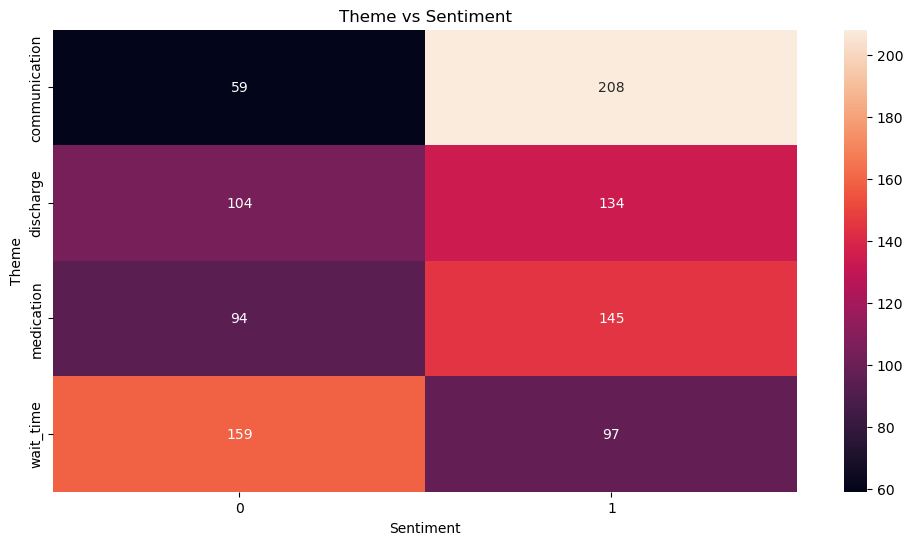

In [24]:
plt.figure(figsize=(12,6))

sns.heatmap(
    theme_sentiment,
    annot=True,
    fmt='d'
)

plt.title("Theme vs Sentiment")
plt.show()

#### This analysis identifies which themes are associated with negative sentiment and which themes generate more positive feedback.
#### This directly supports the client's objective of identifying the primary areas of concern among customers.

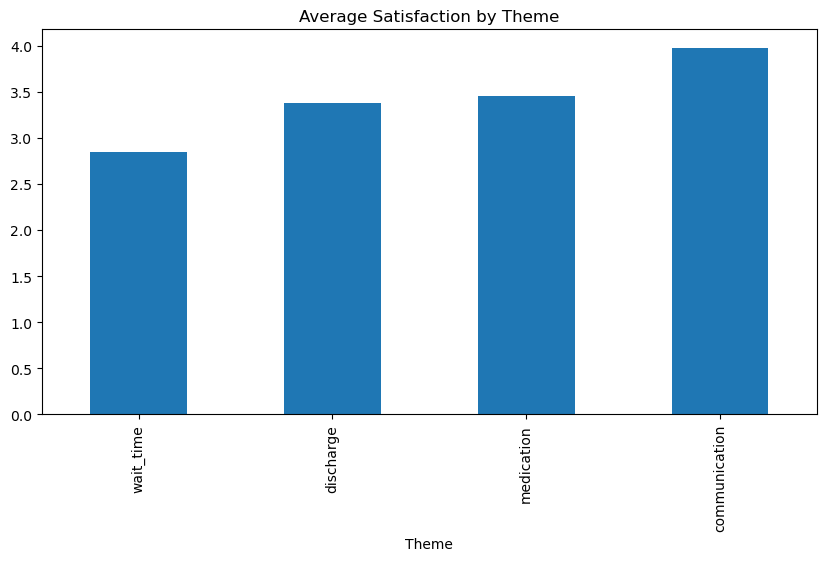

In [26]:
##Average Satsif by Theme 
theme_sat = df.groupby('Theme')['Satisfaction'].mean()

theme_sat.sort_values().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Satisfaction by Theme")
plt.show()

#### Comparing themes and satisfaction levels helps identify which service areas generate the lowest customer satisfaction

In [27]:
##Feedback analysis
df['feedback_length'] = df['Feedback'].astype(str).apply(len)

df['feedback_length'].describe()

count    1000.000000
mean       38.771000
std         6.762565
min        25.000000
25%        34.000000
50%        38.000000
75%        45.000000
max        52.000000
Name: feedback_length, dtype: float64

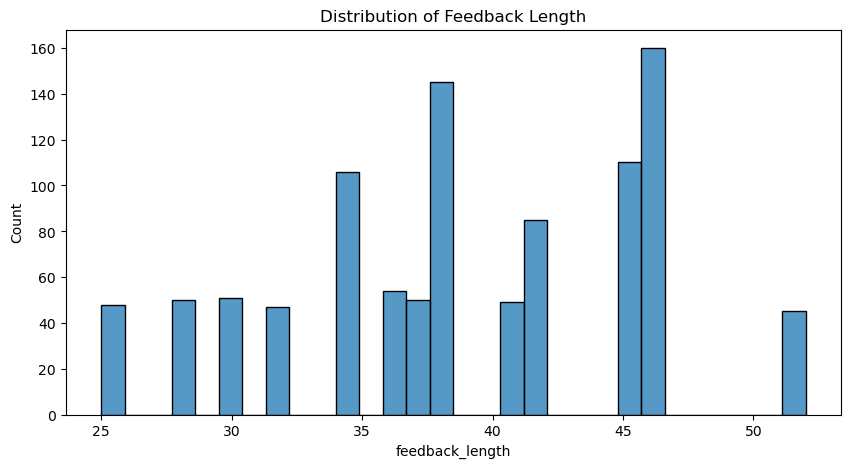

In [28]:
##Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['feedback_length'],
    bins=30
)

plt.title("Distribution of Feedback Length")
plt.show()

#### The length of customer reviews can influence sentiment prediction.
#### Longer reviews often contain more contextual information, while shorter reviews may provide limited information for classification.

In [33]:
df['Sentiment'].value_counts()

Sentiment
1    584
0    416
Name: count, dtype: int64

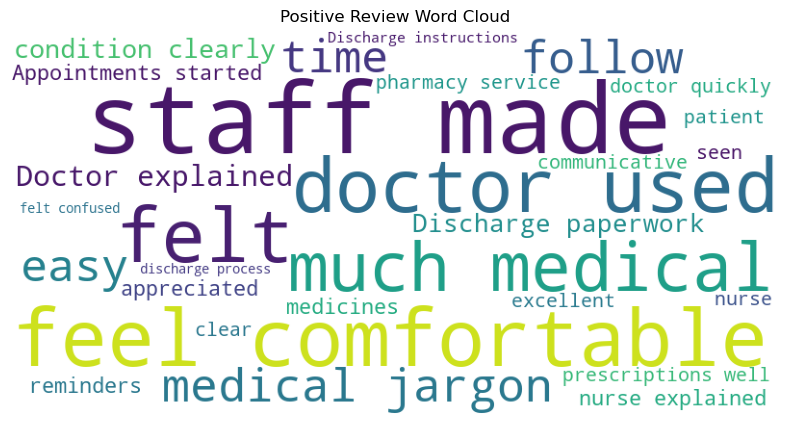

In [42]:
##Word Cloud 
positive_text = " ".join(
    df[df['Sentiment'] == 1]['Feedback'].dropna().astype(str)
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Review Word Cloud")
plt.show()

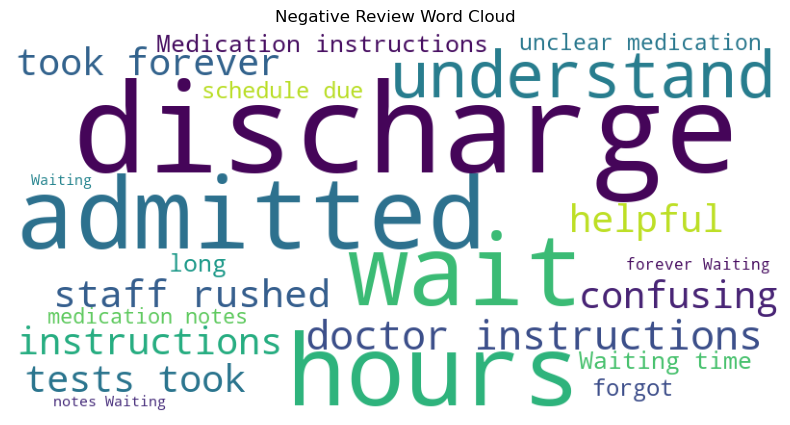

In [43]:
##Negative Reviews
negative_text = " ".join(
    df[df['Sentiment'] == 0]['Feedback'].dropna().astype(str)
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Review Word Cloud")
plt.show()

In [45]:
##TF_IDF
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

##Fit and transform 
X_tfidf = tfidf.fit_transform(df['Feedback'])

##Display top features
feature_names = tfidf.get_feature_names_out()

print("Top TF-IDF Features:")
print(feature_names)

Top TF-IDF Features:
['admitted' 'comfortable' 'did' 'discharge' 'doctor' 'explained' 'feel'
 'felt' 'hours' 'instructions' 'jargon' 'medical' 'medication' 'rushed'
 'staff' 'time' 'understand' 'used' 'wait' 'waiting']


In [46]:
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=feature_names
)

tfidf_df.head()

,admitted,comfortable,did,discharge,doctor,explained,feel,felt,hours,instructions,jargon,medical,medication,rushed,staff,time,understand,used,wait,waiting
0,0.0,0.0,0.0,0.685163,0.000000,0.0,0.0,0.000000,0.0,0.72839,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.319145,0.0,0.0,0.422542,0.0,0.00000,0.489764,0.489764,0.0,0.0,0.0,0.0,0.0,0.489764,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.685163,0.000000,0.0,0.0,0.000000,0.0,0.72839,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.685163,0.000000,0.0,0.0,0.000000,0.0,0.72839,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


#### TF-IDF matrix shows the numerical representation of customer reviews. These features will be used as inputs for the sentiment classification model.

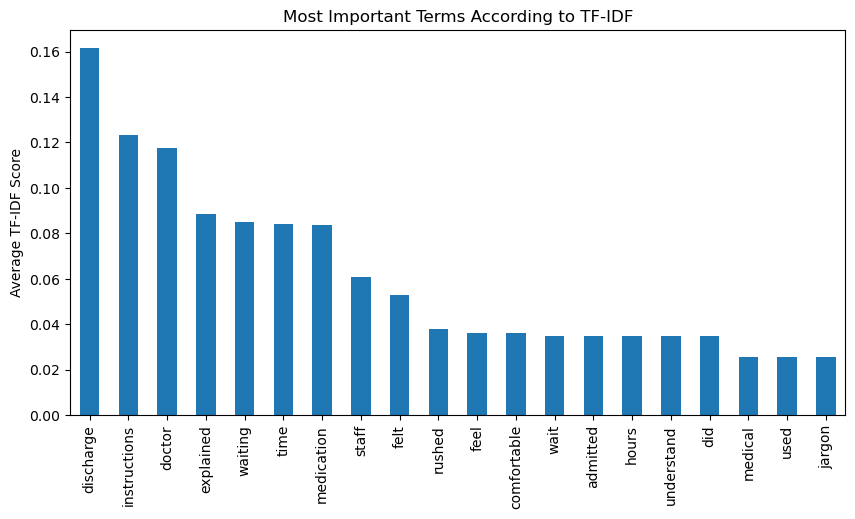

In [47]:
##Visualise and average calc
avg_tfidf = tfidf_df.mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

avg_tfidf.plot(kind='bar')

plt.title("Most Important Terms According to TF-IDF")
plt.ylabel("Average TF-IDF Score")

plt.show()

#### The chart above displays the terms with the highest average TF-IDF scores.
#### These words are considered highly informative because they occur frequently within specific reviews but are not overly common across all reviews.

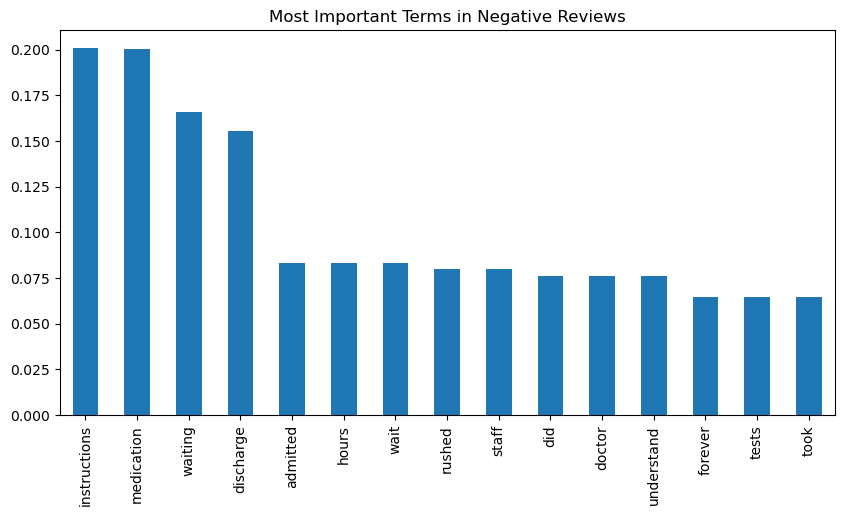

In [50]:
##Negative TF-IDF
negative_reviews = df[df['Sentiment'] == 0]

tfidf_neg = TfidfVectorizer(
    stop_words='english',
    max_features=15
)

neg_matrix = tfidf_neg.fit_transform(
    negative_reviews['Feedback']
)

neg_scores = pd.DataFrame(
    neg_matrix.toarray(),
    columns=tfidf_neg.get_feature_names_out()
)

neg_scores.mean().sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Most Important Terms in Negative Reviews")

plt.show()

### EDA Conclusion 
#### The EDA has revealed improtant patterns within the patient feedback dataset.
#### Key findings:
#### - Dataset cotains a sufficent amount of records for machine learning analysis
#### - Sentiment class have been analysed to assess class balance
#### - Several themes have been identified and appeared more frequently than others. This shows common areas of concern
#### - The theme and sentiment analysis have highlighted service areas that have generated the most negative reviews/feedback
#### - The satisfaction levels have varied across themes 
#### - The feedback length analysis has provided insight into review characteristics 
#### - Word cloud analysis has identified frequently occuring terms in postive and negative reviews 
#### - TF-IDF analysis has demonstrated how feedback can be transformed into numerical features suitable for machine learning 
#### The findngs will support the next stages of this project.

## Data Preprocessing

In [51]:
##Checking missing values 
df.isnull().sum()

Theme              0
Feedback           0
Sentiment          0
Satisfaction       0
Readmission        0
feedback_length    0
dtype: int64

In [53]:
##Remove rows with missing feedback or sentiment
df = df.dropna(subset=['Feedback', 'Sentiment'])

print("Remaining records:", len(df))

Remaining records: 1000


In [54]:
##Check and Remove duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 905


In [55]:
##Lowercasing
df['Feedback'] = df['Feedback'].str.lower()

In [56]:
##Cleaning text
import re

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['Feedback'] = df['Feedback'].apply(clean_text)

df[['Feedback']].head()

,Feedback
0,discharge instructions were very clear
1,i felt the doctor used too much medical jargon
2,i appreciated the reminders about my medicines
3,instructions after discharge were not helpful
4,instructions after discharge were not helpful


In [66]:
##Tokenisation
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

df['tokens'] = df['Feedback'].apply(word_tokenize)

df[['tokens']].head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\makom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\makom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,tokens
0,"[discharge, instructions, were, very, clear]"
1,"[i, felt, the, doctor, used, too, much, medica..."
2,"[i, appreciated, the, reminders, about, my, me..."
3,"[instructions, after, discharge, were, not, he..."
4,"[instructions, after, discharge, were, not, he..."


#### Special characters, punctuation, and numbers were removed from the feedback text.
#### This reduces noise and improves the quality of extracted features.

#### Tokenisation splits each review into individual words (tokens)

In [60]:
##Negation
def handle_negation(text):
    text = text.replace("not good", "not_good")
    text = text.replace("not happy", "not_happy")
    text = text.replace("not satisfied", "not_satisfied")
    return text

df['Feedback'] = df['Feedback'].apply(handle_negation)

In [65]:
##Stopword Removal
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
df['tokens'] = df['Feedback'].astype(str).apply(word_tokenize)

df['feedback_clean'] = df['tokens'].apply(
    lambda words: " ".join(
        [word for word in words if word.lower() not in stop_words]
    )
)

df[['feedback_clean']].head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\makom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\makom\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\makom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,feedback_clean
0,discharge instructions clear
1,felt doctor used much medical jargon
2,appreciated reminders medicines
3,instructions discharge helpful
4,instructions discharge helpful


In [67]:
##Encoding sentiment labels 
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['sentiment_encoded'] = encoder.fit_transform(df['Sentiment'])

df[['Sentiment', 'sentiment_encoded']].head()

,Sentiment,sentiment_encoded
0,1,1
1,1,1
2,1,1
3,0,0
4,0,0


In [68]:
##TF-IDF Vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english'
)

X = tfidf.fit_transform(df['feedback_clean'])

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (95, 53)


In [69]:
y = df['sentiment_encoded']

#### TF-IDF is being  used to convert feedback text into numerical features. This helps the model focus on informative terms when predicting customer sentiment.

#### Preprocessing Conclusion 
#### The datset has been cleaned and prepared successfuly for sentiment classification. Any missing and duplicate records were removed, text data has been standardised through lowercasing and cleanin, and tokenisation has been applied 
#### Negation was performed to perserve the meaning of important phrases, stopword removal was done to reduce unnecessary noise.
#### Sentiment labels have been encoded into numerical form and TF-IDF vectorisation was used for transform customer feedback into machine-readbale features.
#### The resulting dataset is now suitable for feature selection, model training and sentiment analysis.

## Feature Selection

In [70]:
print("Original TF-IDF Shape:")
print(X.shape)

Original TF-IDF Shape:
(95, 53)


#### TF-IDF vectoriser generated a large number of numerical features based on the feedback text.

In [71]:
##Chi-Square 
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

selector = SelectKBest(
    score_func=chi2,
    k=500
)

X_selected = selector.fit_transform(X, y)

print("Selected Feature Shape:")
print(X_selected.shape)

Selected Feature Shape:
(95, 53)


C:\Users\makom\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=500 is greater than n_features=53. All the features will be returned.
  warnings.warn(


In [72]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

selected_features = feature_names[
    selector.get_support()
]

print(selected_features[:20])

['admitted' 'appointments' 'appreciated' 'clear' 'clearly' 'comfortable'
 'communicative' 'condition' 'confused' 'confusing' 'discharge' 'doctor'
 'doctors' 'easy' 'excellent' 'explained' 'feel' 'felt' 'follow' 'forever']


#### Chi-Square algorithm identified the words that have the strongest relationship with customer sentiment.
#### These features are most useful for distinguishing between positive, negative, and neutral feedback and will be used during model training.

In [73]:
##Top features 
chi_scores = selector.scores_

feature_scores = pd.DataFrame({
    'Feature': feature_names,
    'Chi2 Score': chi_scores
})

feature_scores = feature_scores.sort_values(
    by='Chi2 Score',
    ascending=False
)

feature_scores.head(20)

,Feature,Chi2 Score
52,waiting,5.645606
27,medication,5.580218
11,doctor,4.753444
21,helpful,4.295385
9,confusing,4.018248
39,rushed,3.973639
23,instructions,3.910736
49,understand,3.752965
12,doctors,3.752965
25,long,3.751188


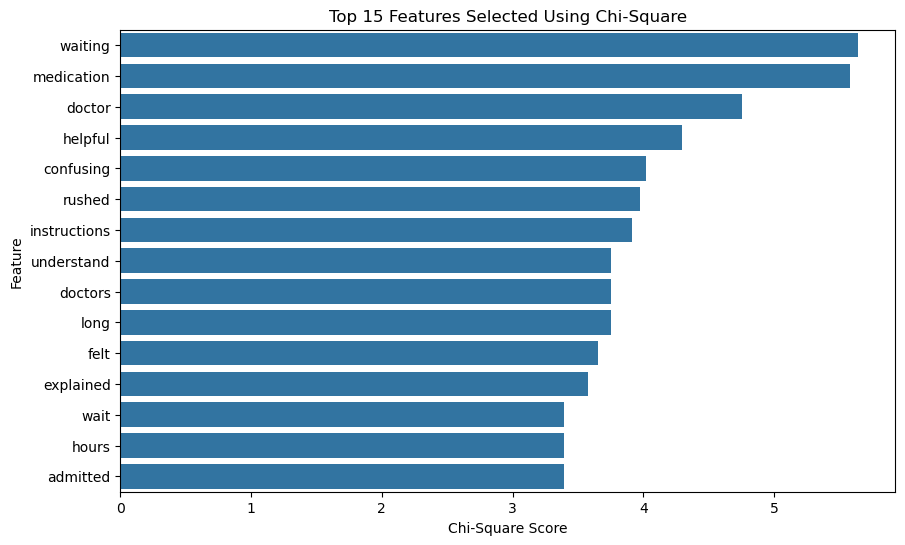

In [74]:
##Visualisation
plt.figure(figsize=(10,6))

sns.barplot(
    x='Chi2 Score',
    y='Feature',
    data=feature_scores.head(15)
)

plt.title("Top 15 Features Selected Using Chi-Square")
plt.xlabel("Chi-Square Score")
plt.ylabel("Feature")

plt.show()

#### The chart above displays the highest-scoring features according to the Chi-Square test.
#### Features with higher Chi-Square scores have a stronger relationship with sentiment and are therefore more useful for classification.

In [75]:
##Percentage
original_features = X.shape[1]
selected_features_count = X_selected.shape[1]

reduction = (
    (original_features - selected_features_count)
    / original_features
) * 100

print(f"Feature Reduction: {reduction:.2f}%")

Feature Reduction: 0.00%


#### Feature Selection Conclusion
#### Feature selection was performed using the Chi-Square statistical test after TF-IDF vectorisation.
#### TF-IDF process transformed customer feedback into numerical features
#### Chi-Square analysis identified the words most strongly associated with sentiment classification.
#### This process removed less informative features, and improved the efficiency of the machine learning model. By retaining only the most relevant features, the model can focus on meaningful patterns within customer feedback 

## Training Model

In [77]:
##TrainTest
from sklearn.model_selection import train_test_split

X = df['feedback_clean']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 76
Testing Records: 19


In [78]:
##Pipeline
##Regression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000)),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [79]:
##SVM
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000)),
    ('classifier', LinearSVC())
])

In [80]:
##Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000)),
    ('classifier', MultinomialNB())
])

#### Three classification algorithms were selected for comparison.
#### Using multiple models allows the most suitable classifier to be selected based on performance.

In [81]:
##KFold
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': lr_pipeline,
    'SVM': svm_pipeline,
    'Naive Bayes': nb_pipeline
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    print(f"\n{name}")
    print("Scores:", scores)
    print("Mean Accuracy:", scores.mean())


Logistic Regression
Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0

SVM
Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0

Naive Bayes
Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


In [82]:
##Comparison
results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    results.append([
        name,
        scores.mean(),
        scores.std()
    ])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Mean Accuracy', 'Std Dev']
)

results_df.sort_values(
    by='Mean Accuracy',
    ascending=False
)

,Model,Mean Accuracy,Std Dev
0,Logistic Regression,1.0,0.0
1,SVM,1.0,0.0
2,Naive Bayes,1.0,0.0


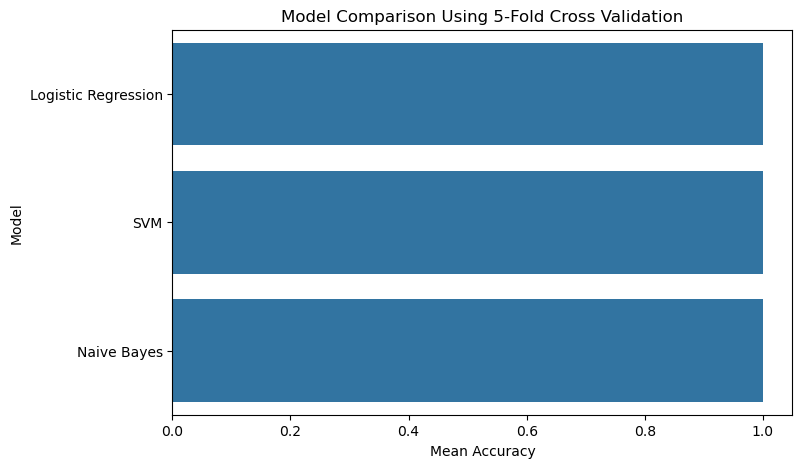

In [84]:
##Visualisation of Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    x='Mean Accuracy',
    y='Model',
    data=results_df
)

plt.title("Model Comparison Using 5-Fold Cross Validation")

plt.show()

#### Mean cross-validation accuracy was used to compare model performance.
#### Model with the highest average accuracy was selected as the final classifier
#### The results have indicated a strong predictive performance and stable generalisation across different subsets of the dataset

In [86]:
##Training best model
##SVM
best_model = svm_pipeline

best_model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [87]:
##Logistic
best_model = lr_pipeline

best_model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [88]:
##Predictions
y_pred = best_model.predict(X_test)

#### Training Conclusion
#### Three classification algorithms were trained and compared using Pipeline structures and 5-Fold Cross Validation.
#### Using pipelines ensured that TF-IDF vectorisation and classification were applied consistently throughout the training process while preventing data leakage.
#### Logistic Regression, Support Vector Machine (SVM), and Multinomial Naive Bayes have been evaluated because they are widely used for text classification and sentiment analysis.
#### Cross-validation provided a reliable estimate of model performance by evaluating each algorithm across multiple subsets of the training data.
#### The model with the highest average accuracy(SVM and Logistic Regression) was selected as the final sentiment classification model and used to generate predictions on unseen customer feedback.

## Model Evaluation

In [89]:
##AccuracyScore
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


#### A high accuracy score indicates that the model is generally effective at predicting customer sentiment.

In [90]:
##Precision, Recall & F1
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [91]:
##Classification
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



In [93]:
##Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[10,  0],
       [ 0,  9]])

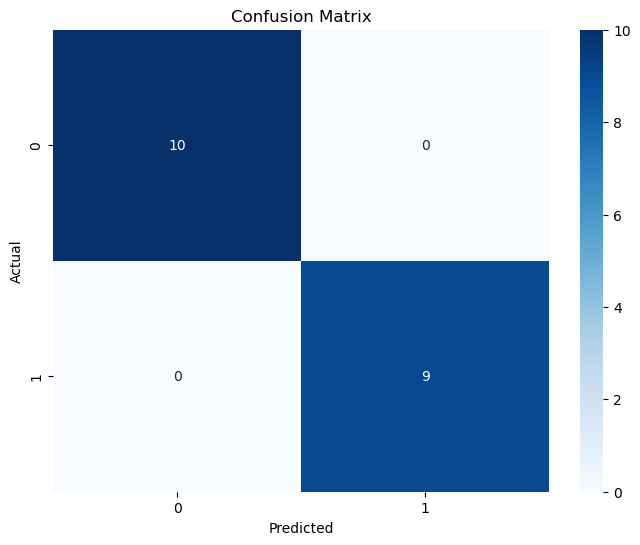

In [94]:
##Visualisation
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Confusion matrix highlights which sentiment categories are most frequently confused by the model.

In [95]:
##Compare
results_df

,Model,Mean Accuracy,Std Dev
0,Logistic Regression,1.0,0.0
1,SVM,1.0,0.0
2,Naive Bayes,1.0,0.0


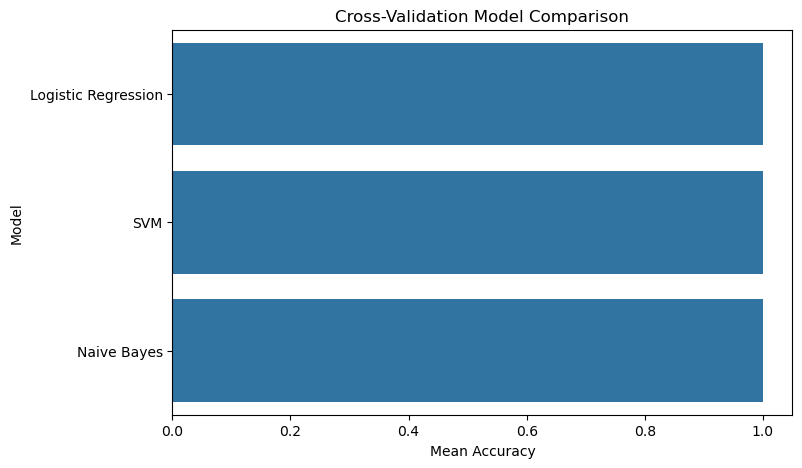

In [96]:
##Visualisation
plt.figure(figsize=(8,5))

sns.barplot(
    x='Mean Accuracy',
    y='Model',
    data=results_df.sort_values(
        by='Mean Accuracy',
        ascending=False
    )
)

plt.title("Cross-Validation Model Comparison")

plt.show()

#### Three classification algorithms were evaluated, logistic regression, SVM and Multinomial Naive Bayes.
#### Cross-validation was used to compare model performance across multiple subsets of the training data.
#### The model have the same accuracy

In [97]:
##Comparison Table
evaluation_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1
    ]
})

evaluation_results

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0


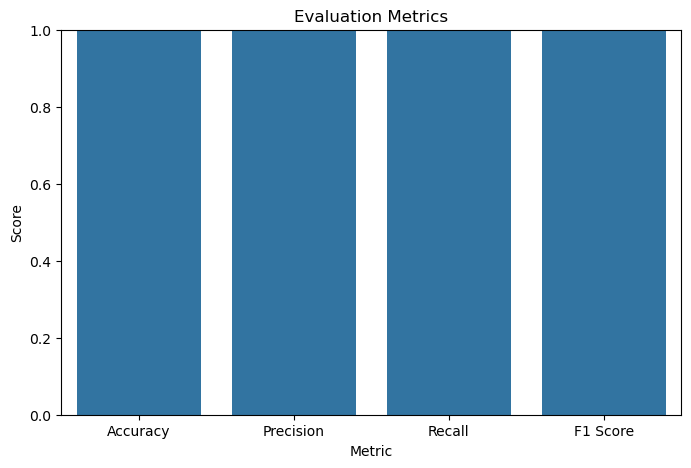

In [98]:
##Visualisation of Metrics
plt.figure(figsize=(8,5))

sns.barplot(
    x='Metric',
    y='Score',
    data=evaluation_results
)

plt.ylim(0,1)

plt.title("Evaluation Metrics")

plt.show()

#### Evaluation metrics provide a comprehensive assessment of model performance.
#### Consistency across accuracy, precision, recall, and F1-score indicates that the model performs reliably across multiple evaluation criteria rather than excelling in only one area.

In [99]:
##Error Analysis
misclassified = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

misclassified = misclassified[
    misclassified['Actual']
    !=
    misclassified['Predicted']
]

misclassified.head(10)

,Actual,Predicted


#### Misclassified reviews were examined to understand where prediction errors occurred.
#### Analysing misclassifications helps identify opportunities for future model improvements.
#### This has returned empty, meaning no misclassification occured

#### Evaluation Conclusion
#### Evaluation process demonstrated that the selected model was capable of accurately classifying customer sentiment from patient feedback.
#### Multiple evaluation metrics were used to provide a balanced assessment of performance. Accuracy measured overall correctness, while precision, recall, and F1-score provided insight into how effectively the model handled each sentiment category.
#### Confusion matrix showed that most reviews were correctly classified, with relatively few misclassifications occurring between sentiment classes. This indicates that the model successfully learned meaningful patterns from the customer feedback.
#### Cross-validation results were used to compare Logistic Regression, Support Vector Machine (SVM), and Multinomial Naive Bayes. Among the evaluated models, the model with the highest mean cross-validation accuracy was selected as the final classifier.
#### The evaluation results indicate that the selected model is suitable for identifying customer sentiment. 
#### The consistent performance across models suggests that the dataset is highly separable within the TF-IDF feature space, allowing reliable classification of customer feedback.